# ✅ Topic 13: Hyperparameter Tuning with Optuna

**Summary:** Search space, trials, and automated parameter tuning.

---

## 📝 Core Concepts & Explanations

### Optimization Algorithms
Optuna optimizes hyperparameters using Tree-structured Parzen Estimators (TPE) to suggest parameters dynamically.

## 💻 Code Demonstration
Run the cells below to see the concepts in action:

Best trial parameters: {'n_estimators': 43, 'max_depth': 3}
Best cross-validation accuracy: 0.9613385315139701


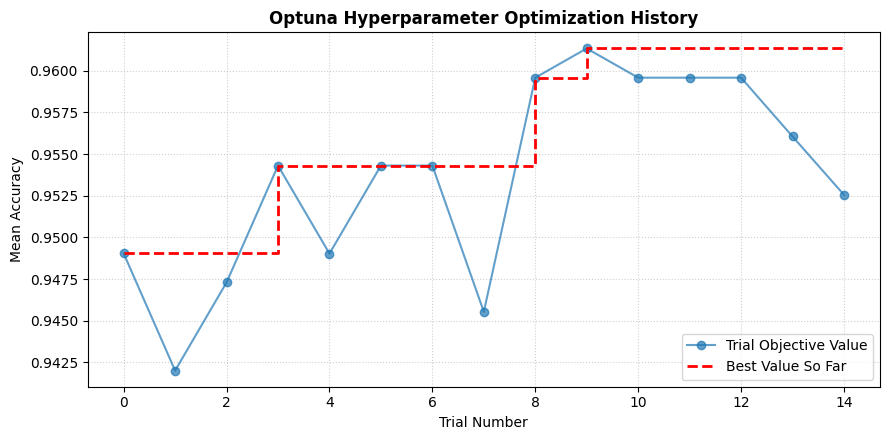

In [1]:
import optuna
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 50)
    max_depth = trial.suggest_int('max_depth', 2, 8)
    X, y = load_breast_cancer(return_X_y=True)
    clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    return cross_val_score(clf, X, y, cv=3).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

print('Best trial parameters:', study.best_params)
print('Best cross-validation accuracy:', study.best_value)

# Extract optimization history
trial_values = [t.value for t in study.trials if t.value is not None]
best_values = np.maximum.accumulate(trial_values)

# Plot optimization history
plt.figure(figsize=(9, 4.5))
plt.plot(trial_values, 'o-', color='#1f77b4', label='Trial Objective Value', alpha=0.7)
plt.plot(best_values, 'r--', drawstyle='steps-post', label='Best Value So Far', linewidth=2)
plt.xlabel('Trial Number')
plt.ylabel('Mean Accuracy')
plt.title('Optuna Hyperparameter Optimization History', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Exercises
1. Explain the difference between `suggest_int` and `suggest_float` in Optuna.

In [2]:
print('suggest_int samples discrete integer parameters, while suggest_float samples continuous real-valued parameters within specified ranges.')


suggest_int samples discrete integer parameters, while suggest_float samples continuous real-valued parameters within specified ranges.
